# Threshold Predictor (Tabular Regression) — Training Notebook

This notebook trains and evaluates a regression model to predict **`T_threshold`** from tabular image features.

**What’s inside**
- Data load & schema checks
- (Optional) Gaussian jitter augmentation
- Baselines (Linear Regression with scaling)
- Tree ensemble (Gradient Boosting) with cross‑validated hyperparameter search
- Held‑out test evaluation (RMSE, MAE, R²)
- Feature importance (gain + permutation)
- Model export (`joblib`)

> References used for design choices (add as citations in the paper):
> - **Cross‑validation & test set**: training and testing on the same data is a methodological mistake; hold out a test set and use cross‑validation for model selection.
> - **Scaling**: linear models benefit from standardization; tree‑based models are almost not affected by scaling.
> - **Tree ensembles**: random forests and gradient boosting combine several estimators to improve generalization and robustness.

Replace file paths if needed. Random seeds are fixed for reproducibility.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ==== Setup ====
import os, math, json, random
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
import joblib
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
df = pd.read_excel('/content/drive/MyDrive/FT_data_final/retrain_dataset.xlsx')

DATA_PATH = Path('/content/drive/MyDrive/FT_data_final/retrain_dataset.xlsx')
OUT_DIR = Path('/content/drive/MyDrive/FT_data_final/artifacts')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Using:', DATA_PATH)


Using: /content/drive/MyDrive/FT_data_final/retrain_dataset.xlsx


In [ ]:

# ==== Load dataset ====
assert DATA_PATH.exists(), f'Data not found at {DATA_PATH}'
df = pd.read_excel(DATA_PATH)
feature_cols = ['p10','skew','kurtosis','contrast']

#feature_cols = ['p10','p90','int_min','int_max','int_range','skew','kurtosis','contrast','homogeneity']
target_col   = 'T_threshold'
missing = set(feature_cols + [target_col]) - set(df.columns)
assert not missing, f'Missing expected columns: {missing}'

X = df[feature_cols].copy()
y = df[target_col].astype(float).copy()

display(df.head(3))
print('Shape:', df.shape)
print('Features:', feature_cols)
print('Target:', target_col)


,mu_s,sigma_s,int_min,int_max,int_range,skew,kurtosis,p10,p90,contrast,homogeneity,image_id,T_threshold
0,132.507282,29.825584,52,179,127,-0.761538,-0.555865,85.1,163.0,228.824641,0.320186,slice_010_139,96.014184
1,73.437126,34.890684,31,150,119,0.589613,-0.992749,35.6,127.2,145.613879,0.243500,slice_015_130,44.223529
2,81.399209,42.891474,31,161,130,0.531717,-1.267553,36.0,146.8,167.891074,0.231448,slice_014_130,45.523077


Shape: (288, 13)
Features: ['p10', 'skew', 'kurtosis', 'contrast']
Target: T_threshold


## Optional: Gaussian jitter augmentation
We can duplicate each training sample and add small **mean‑0 Gaussian noise** to numeric features. Use only on training set, not test.


In [ ]:

def augment_gaussian_jitter(X_in: pd.DataFrame, y_in: pd.Series, std_frac: float = 0.05, copies:int = 2, rng_seed:int = 42):
    rng = np.random.default_rng(rng_seed)
    X_num = X_in.select_dtypes(include=[np.number])
    stds  = X_num.std(ddof=0).replace(0, 1e-8)
    chunks = [X_in]
    targets = [y_in]
    for k in range(copies):
        noise = rng.normal(loc=0.0, scale=std_frac*stds.values, size=X_num.shape)
        X_noisy = X_in.copy()
        X_noisy[X_num.columns] = X_num.values + noise
        chunks.append(X_noisy)
        targets.append(y_in.copy())
    X_aug = pd.concat(chunks, axis=0, ignore_index=True)
    y_aug = pd.concat(targets, axis=0, ignore_index=True)
    return X_aug, y_aug

AUGMENT = True
STD_FRAC = 0.05
COPIES   = 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

if AUGMENT:
    X_train_aug, y_train_aug = augment_gaussian_jitter(X_train, y_train, std_frac=STD_FRAC, copies=COPIES, rng_seed=RANDOM_STATE)
    print('Augmented train shape:', X_train_aug.shape)
else:
    X_train_aug, y_train_aug = X_train, y_train


Augmented train shape: (690, 4)


## Baseline — Linear Regression (with standardization)

In [ ]:

lin_pipe = make_pipeline(StandardScaler(with_mean=True, with_std=True), LinearRegression())
lin_pipe.fit(X_train_aug, y_train_aug)
y_pred_lin = lin_pipe.predict(X_test)
rmse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin  = mean_absolute_error(y_test, y_pred_lin)
r2_lin   = r2_score(y_test, y_pred_lin)
print(f'Linear (scaled) — Test RMSE={rmse_lin:.3f}, MAE={mae_lin:.3f}, R2={r2_lin:.3f}')


Linear (scaled) — Test RMSE=117.643, MAE=7.697, R2=0.540


## Main model — Gradient Boosting Regressor (CV grid search)

In [ ]:

gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)
param_grid = {'n_estimators': [150, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'subsample': [1.0, 0.8]}
cv = 5

gcv = GridSearchCV(gbr, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
gcv.fit(X_train_aug, y_train_aug)
best_gbr = gcv.best_estimator_
print('Best params:', gcv.best_params_)
y_pred_gbr = best_gbr.predict(X_test)
rmse_gbr = mean_squared_error(y_test, y_pred_gbr)
mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr   = r2_score(y_test, y_pred_gbr)
print(f'GradientBoosting — Test RMSE={rmse_gbr:.3f}, MAE={mae_gbr:.3f}, R2={r2_gbr:.3f}')


Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
GradientBoosting — Test RMSE=98.415, MAE=6.332, R2=0.616


## Feature importance

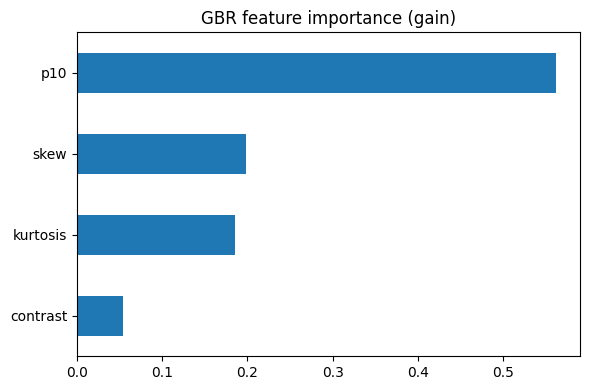

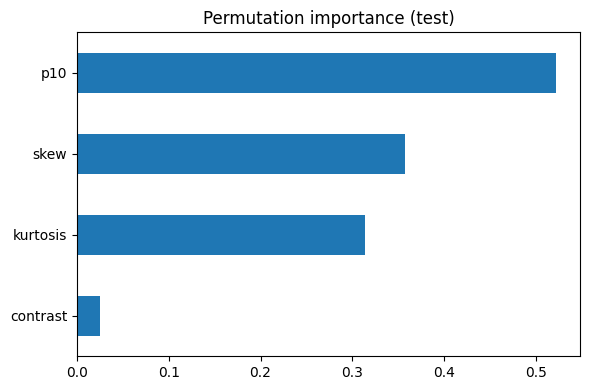

In [ ]:

import matplotlib.pyplot as plt
imp = pd.Series(best_gbr.feature_importances_, index=X.columns).sort_values(ascending=False)
ax = imp.plot(kind='barh', figsize=(6,4))
ax.invert_yaxis()
ax.set_title('GBR feature importance (gain)')
plt.tight_layout()
plt.show()

perm = permutation_importance(best_gbr, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
ax2 = perm_imp.plot(kind='barh', figsize=(6,4))
ax2.invert_yaxis()
ax2.set_title('Permutation importance (test)')
plt.tight_layout()
plt.show()


## Save model & metrics

In [ ]:

import json, joblib
joblib.dump(best_gbr, OUT_DIR/'best_model_gbr.joblib')
metrics = {'linear_scaled': {'rmse': float(rmse_lin), 'mae': float(mae_lin), 'r2': float(r2_lin)},
           'gbr_best':     {'rmse': float(rmse_gbr), 'mae': float(mae_gbr), 'r2': float(r2_gbr)},
           'best_params':   gcv.best_params_,
           'augment':       {'enabled': bool(AUGMENT), 'std_frac': float(STD_FRAC), 'copies': int(COPIES)}}
with open(OUT_DIR/'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved model and metrics to', OUT_DIR)


Saved model and metrics to /content/drive/MyDrive/FT_data_final/artifacts


In [ ]:
lin_pipe = make_pipeline(StandardScaler(with_mean=True, with_std=True), LinearRegression())
lin_pipe.fit(X_train_aug, y_train_aug)
y_pred_lin = lin_pipe.predict(X_test)
rmse_lin = mean_squared_error(y_test, y_pred_lin) # Remove squared=False
mae_lin  = mean_absolute_error(y_test, y_pred_lin)
r2_lin   = r2_score(y_test, y_pred_lin)
print(f'Linear (scaled) — Test RMSE={rmse_lin:.3f}, MAE={mae_lin:.3f}, R2={r2_lin:.3f}')

Linear (scaled) — Test RMSE=117.643, MAE=7.697, R2=0.540


In [ ]:
# --- Absolute determinism settings ---
import os, numpy as np, random
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = "42"

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

from numpy.random import default_rng
RNG = default_rng(RANDOM_STATE)  # use this in augmentation

# Train/test split MUST match
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)

# If you use augmentation, keep these EXACT:
AUGMENT   = True
STD_FRAC  = 0.05   # 5% of per-feature std
COPIES    = 2

def augment_gaussian_jitter(X_in, y_in, std_frac=STD_FRAC, copies=COPIES, rng=RNG):
    X_num = X_in.select_dtypes(include=[np.number])
    stds  = X_num.std(ddof=0).replace(0, 1e-8).values
    Xs, ys = [X_in], [y_in]
    for _ in range(copies):
        noise = rng.normal(0.0, std_frac*stds, size=X_num.shape)
        X_noisy = X_in.copy()
        X_noisy[X_num.columns] = X_num.values + noise
        Xs.append(X_noisy); ys.append(y_in.copy())
    import pandas as pd
    return pd.concat(Xs, ignore_index=True), pd.concat(ys, ignore_index=True)

if AUGMENT:
    X_train_aug, y_train_aug = augment_gaussian_jitter(X_train, y_train)
else:
    X_train_aug, y_train_aug = X_train, y_train

# Gradient Boosting + fixed CV grid
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)
param_grid = {
    "n_estimators": [150, 200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [1.0, 0.8],
}

gcv = GridSearchCV(
    gbr, param_grid, cv=5, scoring="neg_root_mean_squared_error",
    n_jobs=1,  # <- single-thread to avoid any non-deterministic tie timing
    refit=True, verbose=0
)
gcv.fit(X_train_aug, y_train_aug)

best_gbr = gcv.best_estimator_

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = best_gbr.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Best params:", gcv.best_params_)
print(f"GBR — Test RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
GBR — Test RMSE=98.517, MAE=6.345, R2=0.615


In [ ]:
print(X_train_aug.shape)

(690, 4)


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

# If you want to use Gaussian jitter augmentation (optional):
def augment_gaussian_jitter(X_in, y_in, std_frac=0.05, copies=2, seed=42):
    import numpy as np, pandas as pd
    rng = np.random.default_rng(seed)
    X_num = X_in.astype(float)
    stds = X_num.std(ddof=0).replace(0, 1e-8)
    X_list, y_list = [X_in], [y_in]
    for _ in range(copies):
        noise = rng.normal(loc=0.0, scale=std_frac * stds.values, size=X_num.shape)
        X_noisy = X_in + noise
        X_list.append(X_noisy)
        y_list.append(y_in)
    return pd.concat(X_list, ignore_index=True), pd.concat(y_list, ignore_index=True)

# Either augment, or simply set them to X and y if you don’t want augmentation:
# X_aug, y_aug = X, y
X_aug, y_aug = augment_gaussian_jitter(X, y, std_frac=0.05, copies=2)

# Define the cross‑validation strategy and model:
cv = KFold(n_splits=3, shuffle=True, random_state=42)
reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, subsample=1.0,
                                random_state=42)

# Compute mean RMSE via cross‑validation:
scores = -cross_val_score(reg, X_aug, y_aug, cv=cv,
                          scoring='neg_root_mean_squared_error')
print("Fold RMSEs:", scores)
print("Mean RMSE:", scores.mean())


Fold RMSEs: [4.62415809 5.09630025 4.42671447]
Mean RMSE: 4.715724272237909


In [ ]:
# Train the model on the full dataset and save it
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
import joblib

# Load data (adjust path if needed)

# Define features and target
feature_cols = ['p10', 'p90', 'int_min', 'int_max',
                'int_range', 'skew', 'kurtosis',
                'contrast', 'homogeneity']
target_col = 'T_threshold'
X = df[feature_cols]
y = df[target_col]

# (Optional) Gaussian jitter augmentation
def augment_gaussian_jitter(X_in, y_in, std_frac=0.05, copies=2, seed=42):
    rng = np.random.default_rng(seed)
    X_num = X_in.astype(float)
    stds = X_num.std(ddof=0).replace(0, 1e-8)
    X_list, y_list = [X_in], [y_in]
    for _ in range(copies):
        noise = rng.normal(loc=0.0, scale=std_frac * stds.values, size=X_num.shape)
        X_noisy = X_in + noise
        X_list.append(X_noisy)
        y_list.append(y_in)
    return pd.concat(X_list, ignore_index=True), pd.concat(y_list, ignore_index=True)

# Enable augmentation if desired
AUGMENT = True
if AUGMENT:
    X_aug, y_aug = augment_gaussian_jitter(X, y, std_frac=0.05, copies=2)
else:
    X_aug, y_aug = X, y

# Best hyperparameters from our previous grid search
best_params = {
    'n_estimators': 200,
    'learning_rate': 0.1,
    'max_depth': 5,
    'subsample': 1.0
}

# Train final model on full (augmented) data
model = GradientBoostingRegressor(**best_params, random_state=42)
model.fit(X_aug, y_aug)

# Save the model; change this path to your desired drive location
save_path = '/content/drive/MyDrive/best_model_gbr.joblib'  # e.g. '/mnt/drive/MyDrive/best_model_gbr.joblib'
joblib.dump(model, save_path)
print(f"Model saved to {save_path}")


Model saved to /content/drive/MyDrive/best_model_gbr.joblib


Application on Sunny Brook Data


In [ ]:
import os
import numpy as np
import pandas as pd
from skimage import io, morphology
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops
import joblib

# Load trained Gradient Boosting model (update the path if needed)
model_path = '/content/drive/MyDrive/best_model_gbr.joblib'
model = joblib.load(model_path)

# Folders
base_path = '/content/drive/MyDrive/sunnybrooktraining/_reports/per_slice/SCD0000201/top8/'  # <-- update this path
img_folder = os.path.join(base_path, 'images')
mask_folder = os.path.join(base_path, 'gt_masks')
output_gt = os.path.join(base_path, 'scar_outputs/gt_slices')
output_pred = os.path.join(base_path, 'scar_outputs/pred_slices')
os.makedirs(output_gt, exist_ok=True)
os.makedirs(output_pred, exist_ok=True)

# Feature extraction
def extract_features(img, mask):
    region = img[mask > 0]
    min_int  = np.min(region)
    max_int  = np.max(region)
    range_int = max_int - min_int
    skewness = skew(region)
    kurt_val = kurtosis(region)
    p10 = np.percentile(region, 10)
    p90 = np.percentile(region, 90)
    contrast = homogeneity = 0.0
    try:
        glcm = graycomatrix((img * 255).astype('uint8'), [1], [0], levels=256,
                            symmetric=True, normed=True)
        contrast    = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    except Exception:
        pass
    return {
        'p10': p10, 'p90': p90, 'int_min': min_int, 'int_max': max_int,
        'int_range': range_int, 'skew': skewness, 'kurtosis': kurt_val,
        'contrast': contrast, 'homogeneity': homogeneity
    }

# Loop through masks and predict thresholds
for fname in os.listdir(mask_folder):
    if not fname.endswith('.png'):
        continue

    img_id     = fname.replace('.png', '')
    image_path = os.path.join(img_folder, fname)
    mask_path  = os.path.join(mask_folder, fname)

    if not os.path.exists(image_path):
        print(f"Missing image for {img_id}, skipping...")
        continue

    # Load image and mask
    img  = io.imread(image_path, as_gray=True)
    mask = io.imread(mask_path, as_gray=True) > 0

    # Extract features and make a DataFrame
    features = extract_features(img, mask)
    df_feat  = pd.DataFrame([features])

    # Predict the threshold using the gradient boosting model
    T_pred = model.predict(df_feat)[0]
    # Convert to [0,1] if necessary, since skimage loads images in 0–1 range
    if T_pred > 1:
        T_pred = T_pred / 255.0

    print(f"Predicted threshold for {img_id}: {T_pred:.3f}")

    # Segment scar: apply threshold and clean up small objects
    raw_scar = (img > T_pred) & mask
    scar_mask = morphology.remove_small_objects(raw_scar, min_size=20)

    # Save predicted scar and ground truth
    io.imsave(os.path.join(output_pred, fname),
              (scar_mask.astype(np.uint8)) * 255)
    io.imsave(os.path.join(output_gt, fname),
              (mask.astype(np.uint8)) * 255)

    print(f"✅ Processed {img_id}: Saved GT and predicted scar masks")

print("\n✅ All slices processed and saved successfully.")


Predicted threshold for SCD0000201_rank01_slice017: 0.329
✅ Processed SCD0000201_rank01_slice017: Saved GT and predicted scar masks
Predicted threshold for SCD0000201_rank02_slice009: 0.284
✅ Processed SCD0000201_rank02_slice009: Saved GT and predicted scar masks
Predicted threshold for SCD0000201_rank03_slice010: 0.202
✅ Processed SCD0000201_rank03_slice010: Saved GT and predicted scar masks
Predicted threshold for SCD0000201_rank05_slice016: 0.290
✅ Processed SCD0000201_rank05_slice016: Saved GT and predicted scar masks
Predicted threshold for SCD0000201_rank06_slice015: 0.345
✅ Processed SCD0000201_rank06_slice015: Saved GT and predicted scar masks
Predicted threshold for SCD0000201_rank07_slice014: 0.292
✅ Processed SCD0000201_rank07_slice014: Saved GT and predicted scar masks
Predicted threshold for SCD0000201_rank08_slice012: 0.219
✅ Processed SCD0000201_rank08_slice012: Saved GT and predicted scar masks
Predicted threshold for SCD0000201_rank06_slice003: 0.292
✅ Processed SCD000

Test on MM-WHS data

In [ ]:
import os
import numpy as np
import pandas as pd
from skimage import io, morphology
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops
import joblib

# Load trained Gradient Boosting model (update the path if needed)
model_path = '/content/drive/MyDrive/best_model_gbr.joblib'
model = joblib.load(model_path)

# Folders
base_path = '/content/drive/MyDrive/training_data_extracted/'  # <-- update this path
img_folder = os.path.join(base_path, 'saved_slices_patient01/letterbox_images')
mask_folder = os.path.join(base_path, 'saved_slices_patient01/letterbox_masks')
output_gt = os.path.join(base_path, 'scar_outputs/gt_slices')
output_pred = os.path.join(base_path, 'scar_outputs/pred_slices')
os.makedirs(output_gt, exist_ok=True)
os.makedirs(output_pred, exist_ok=True)

# Feature extraction
def extract_features(img, mask):
    region = img[mask > 0]
    min_int  = np.min(region)
    max_int  = np.max(region)
    range_int = max_int - min_int
    skewness = skew(region)
    kurt_val = kurtosis(region)
    p10 = np.percentile(region, 10)
    p90 = np.percentile(region, 90)
    contrast = homogeneity = 0.0
    try:
        glcm = graycomatrix((img * 255).astype('uint8'), [1], [0], levels=256,
                            symmetric=True, normed=True)
        contrast    = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    except Exception:
        pass
    return {
        'p10': p10, 'p90': p90, 'int_min': min_int, 'int_max': max_int,
        'int_range': range_int, 'skew': skewness, 'kurtosis': kurt_val,
        'contrast': contrast, 'homogeneity': homogeneity
    }

# Loop through masks and predict thresholds
for fname in os.listdir(mask_folder):
    if not fname.endswith('.png'):
        continue

    img_id     = fname.replace('.png', '')
    image_path = os.path.join(img_folder, fname)
    mask_path  = os.path.join(mask_folder, fname)

    if not os.path.exists(image_path):
        print(f"Missing image for {img_id}, skipping...")
        continue

    # Load image and mask
    img  = io.imread(image_path, as_gray=True)
    mask = io.imread(mask_path, as_gray=True) > 0

    # Extract features and make a DataFrame
    features = extract_features(img, mask)
    df_feat  = pd.DataFrame([features])

    # Predict the threshold using the gradient boosting model
    T_pred = model.predict(df_feat)[0]
    # Convert to [0,1] if necessary, since skimage loads images in 0–1 range
    if T_pred > 1:
        T_pred = T_pred / 255.0

    print(f"Predicted threshold for {img_id}: {T_pred:.3f}")

    # Segment scar: apply threshold and clean up small objects
    raw_scar = (img > T_pred) & mask
    scar_mask = morphology.remove_small_objects(raw_scar, min_size=20)

    # Save predicted scar and ground truth
    io.imsave(os.path.join(output_pred, fname),
              (scar_mask.astype(np.uint8)) * 255)
    io.imsave(os.path.join(output_gt, fname),
              (mask.astype(np.uint8)) * 255)

    print(f"✅ Processed {img_id}: Saved GT and predicted scar masks")

print("\n✅ All slices processed and saved successfully.")


Missing image for mask_slice001, skipping...
Missing image for mask_slice005, skipping...
Missing image for mask_slice007, skipping...
Missing image for mask_slice002, skipping...
Missing image for mask_slice004, skipping...
Missing image for mask_slice006, skipping...

✅ All slices processed and saved successfully.


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load dataset
# Drop non-feature column
X = df.drop(columns=['T_threshold', 'image_id','p90','int_min','int_max','int_range','homogeneity'])
y = df['T_threshold']

# Define model pipeline
model = make_pipeline(StandardScaler(), GradientBoostingRegressor(random_state=42))

# Define sample sizes for evaluation
sample_sizes = [30, 50, 80, 100, 120, 150, 180, 210, 240, len(df)]

results = []

for n in sample_sizes:
    # Sample data with a fixed random state for reproducibility
    sampled_df = df.sample(n=n, random_state=42)
    X_sample = sampled_df.drop(columns=['T_threshold', 'image_id','p90','int_min','int_max','int_range','homogeneity'])
    y_sample = sampled_df['T_threshold']
    # Determine number of folds based on sample size
    folds = 5 if n >= 5 else max(3, n)
    cv = KFold(n_splits=folds, shuffle=True, random_state=42)
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    for train_idx, test_idx in cv.split(X_sample):
        X_train, X_test = X_sample.iloc[train_idx], X_sample.iloc[test_idx]
        y_train, y_test = y_sample.iloc[train_idx], y_sample.iloc[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2_scores.append(r2_score(y_test, y_pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        mae_scores.append(mean_absolute_error(y_test, y_pred))
    results.append({
        'sample_size': n,
        'r2_mean': np.mean(r2_scores),
        'r2_std': np.std(r2_scores),
        'rmse_mean': np.mean(rmse_scores),
        'rmse_std': np.std(rmse_scores),
        'mae_mean': np.mean(mae_scores),
        'mae_std': np.std(mae_scores),
    })

results_df = pd.DataFrame(results)
# Save to CSV
results_df.to_csv('performance_metrics.csv', index=False)
print(results_df)


   sample_size   r2_mean    r2_std  rmse_mean  rmse_std  mae_mean   mae_std
0           30  0.221003  0.918594  11.320893  5.050906  9.169299  3.970329
1           50  0.707230  0.146965   7.519364  1.081227  6.173314  1.080068
2           80  0.590109  0.211785   9.455882  3.019600  7.039932  1.898522
3          100  0.616363  0.190065   9.157730  2.173997  6.728072  1.223462
4          120  0.688980  0.176247   8.637671  2.292512  6.462005  1.184319
5          150  0.715812  0.130761   8.288679  1.831978  6.241773  1.276181
6          180  0.678121  0.191625   9.250966  2.109768  5.872735  0.771994
7          210  0.707603  0.160660   8.662943  2.154234  5.543079  0.789642
8          240  0.795017  0.115617   7.708578  2.815798  4.883819  1.120287
9          288  0.786227  0.084515   7.745929  1.722678  4.955178  0.624529
